NQS Day 1 
======================================

Requirements:
numpy, scipy, matplotlib, torch
(Install with: pip install numpy scipy matplotlib torch)

In [3]:
import numpy as np
from scipy import sparse
from scipy.sparse import linalg as spla
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim

import itertools, time

## Problem 1.1 Background

We will use ED code to find the grounstate of the 1D TFI model for a chain of N spins. 

In [ ]:
"""
Exact Diagonalization (ED) of the 1D Transverse Field Ising (TFI) Model

    H = -J * sum_i sigma_i^z sigma_{i+1}^z  -  h * sum_i sigma_i^x

Basis: computational basis |s_0, s_1, ..., s_{N-1}> where s_i in {0,1}
  |0> = spin-up   (+1 eigenvalue of sigma^z)
  |1> = spin-down (-1 eigenvalue of sigma^z)

Periodic boundary conditions (PBC) are used by default.

Phase diagram (N -> infinity):
  h < J : ferromagnetic (Z2-broken) phase
  h = J : critical point (CFT: Ising universality class, c=1/2)
  h > J : paramagnetic (disordered) phase
"""

# Hamiltonian construction

def build_hamiltonian(N: int, J: float, h: float, pbc: bool = True):
    """
    Build the TFI Hamiltonian as a sparse matrix in the 2^N computational basis.

    Parameters
    ----------
    N   : number of spins
    J   : Ising coupling  (J > 0 → ferromagnetic)
    h   : transverse field strength
    pbc : periodic boundary conditions

    Returns
    -------
    H : scipy csr_matrix of shape (2^N, 2^N)
    """
    dim = 2 ** N
    H = lil_matrix((dim, dim), dtype=float)

    for state in range(dim):
        # ── sigma^z_i sigma^z_{i+1} (diagonal) ──────────────────────────────
        for i in range(N - 1):
            si = (state >> i) & 1      # bit i  (0=up, 1=down)
            sj = (state >> (i+1)) & 1  # bit i+1
            sz_i = 1 - 2 * si          # maps {0,1} -> {+1,-1}
            sz_j = 1 - 2 * sj
            H[state, state] -= J * sz_i * sz_j

        if pbc:
            # wrap-around bond: spin N-1 ↔ spin 0
            # TODO implement periodoc boundary conditions
            s0 = state & 1
            sN_minus_1 = (state >> (N-1)) & 1
            sz_0 = 1 - 2*s0
            sz_N_minus_1 = 1 - 2*sN_minus_1
            H[state, state] -= J * sz_0 * sz_N_minus_1

        # ── sigma^x_i (off-diagonal: flips bit i) ───────────────────────────
        for i in range(N):
            # TODO implement off-diagonal elements
            state2 = state ^ (1 << i)
            H[state, state2] += - h 
    return csr_matrix(H)

In [90]:
H = build_hamiltonian(3, 0, 1, pbc=False)
print(H.toarray())

[[ 0. -1. -1.  0. -1.  0.  0.  0.]
 [-1.  0.  0. -1.  0. -1.  0.  0.]
 [-1.  0.  0. -1.  0.  0. -1.  0.]
 [ 0. -1. -1.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0. -1. -1.  0.]
 [ 0. -1.  0.  0. -1.  0.  0. -1.]
 [ 0.  0. -1.  0. -1.  0.  0. -1.]
 [ 0.  0.  0. -1.  0. -1. -1.  0.]]


In [91]:
sx = -np.array([[0, 1],
               [1, 0]])

id = np.array([[1, 0],
              [0, 1]])

np.kron(sx, np.eye(4)) + np.kron(id, np.kron(sx, id)) + np.kron(np.eye(4), sx)

array([[ 0., -1., -1.,  0., -1.,  0.,  0.,  0.],
       [-1.,  0.,  0., -1.,  0., -1.,  0.,  0.],
       [-1.,  0.,  0., -1.,  0.,  0., -1.,  0.],
       [ 0., -1., -1.,  0.,  0.,  0.,  0., -1.],
       [-1.,  0.,  0.,  0.,  0., -1., -1.,  0.],
       [ 0., -1.,  0.,  0., -1.,  0.,  0., -1.],
       [ 0.,  0., -1.,  0., -1.,  0.,  0., -1.],
       [ 0.,  0.,  0., -1.,  0., -1., -1.,  0.]])

In [ ]:
# Observables

def magnetization_z(psi: np.ndarray, N: int) -> float:
    """
    <psi| (1/N) sum_i sigma^z_i |psi>
    Measures ferromagnetic order parameter.
    """
    dim = 2 ** N
    m = 0.0
    for state in range(dim):
        amp2 = abs(psi[state]) ** 2
        sz_total = sum(1 - 2 * ((state >> i) & 1) for i in range(N))
        m += amp2 * sz_total
    return m / N


def magnetization_x(psi: np.ndarray, N: int) -> float:
    """
    <psi| (1/N) sum_i sigma^x_i |psi>
    Measures paramagnetic order parameter.
    """
    dim = 2 ** N
    mx = 0.0
    for state in range(dim):
        for i in range(N):
            flipped = state ^ (1 << i)
            mx += psi[state].conj() * psi[flipped]
    return (mx / N).real


def energy_density(E0: float, N: int) -> float:
    return E0 / N


# Main solver

def solve_tfi(N: int, J: float, h: float, pbc: bool = True, n_states: int = 4):
    """
    Solve for the lowest n_states eigenstates of the TFI model.

    Returns
    -------
    energies : ndarray of shape (n_states,)
    states   : ndarray of shape (2^N, n_states)
    gap      : first excitation gap E1 - E0
    """
    H = build_hamiltonian(N, J, h, pbc)
    # eigsh returns eigenvalues in ascending order
    n_eig = min(n_states, 2**N)
    energies, states = eigsh(H, k=n_eig, which='SA')
    idx = np.argsort(energies)
    energies = energies[idx]
    states = states[:, idx]
    gap = energies[1] - energies[0] if n_eig > 1 else None
    return energies, states, gap


  TFI Exact Diagonalization   N = 12,  PBC
  H = -J Σ σᶻᵢσᶻᵢ₊₁ - h Σ σˣᵢ   (J = 1.0)

── h < J  (ferromagnetic) ──
   h/J = 0.30
   E0/N          = -1.022630
   Gap (E1-E0)   = 0.000000
   |<σᶻ>|        = 0.000000  (ferro order param)
   |<σˣ>|        = 0.151748  (para  order param)
   Lowest 6 E's  = [-12.27155426 -12.27155409  -9.4137383   -9.36107767  -9.36107767
  -9.25060124]

── h = J  (critical) ──
   h/J = 1.00
   E0/N          = -1.276883
   Gap (E1-E0)   = 0.131087
   |<σᶻ>|        = 0.000000  (ferro order param)
   |<σˣ>|        = 0.638441  (para  order param)
   Lowest 6 E's  = [-15.32259515 -15.19150823 -14.27838561 -14.15623205 -14.15623205
 -13.26975665]

── h > J  (paramagnetic) ──
   h/J = 3.00
   E0/N          = -3.083929
   Gap (E1-E0)   = 4.000002
   |<σᶻ>|        = 0.000000  (ferro order param)
   |<σˣ>|        = 0.971615  (para  order param)
   Lowest 6 E's  = [-37.00714711 -33.0071453  -32.62360902 -32.62360902 -31.71564268
 -31.71564268]


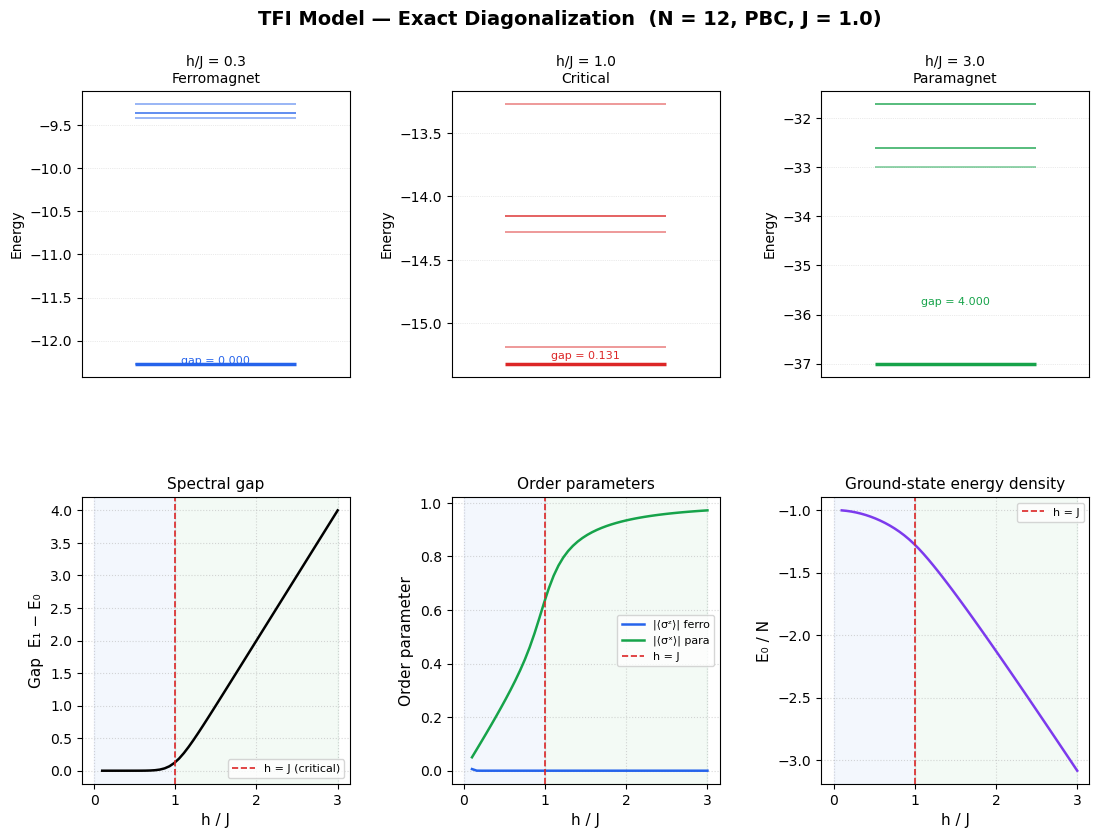

In [ ]:

# Demonstration: three regimes + phase diagram scan

def demo(N: int = 8):
    J = 1.0
    regimes = [
        ("h < J  (ferromagnetic)",  0.3 * J),
        ("h = J  (critical)",       1.0 * J),
        ("h > J  (paramagnetic)",   3.0 * J),
    ]

    print("=" * 62)
    print(f"  TFI Exact Diagonalization   N = {N},  PBC")
    print(f"  H = -J Σ σᶻᵢσᶻᵢ₊₁ - h Σ σˣᵢ   (J = {J})")
    print("=" * 62)

    results = []
    for label, h in regimes:
        energies, states, gap = solve_tfi(N, J, h, pbc=True, n_states=6)
        gs = states[:, 0]
        mz  = abs(magnetization_z(gs, N))
        mx  = abs(magnetization_x(gs, N))
        e0  = energy_density(energies[0], N)

        results.append(dict(label=label, h=h, energies=energies,
                            gap=gap, mz=mz, mx=mx, e0=e0))

        print(f"\n── {label} ──")
        print(f"   h/J = {h/J:.2f}")
        print(f"   E0/N          = {e0:.6f}")
        print(f"   Gap (E1-E0)   = {gap:.6f}")
        print(f"   |<σᶻ>|        = {mz:.6f}  (ferro order param)")
        print(f"   |<σˣ>|        = {mx:.6f}  (para  order param)")
        print(f"   Lowest 6 E's  = {energies[:6]}")

    # ── phase diagram scan ───────────────────────────────────────────────────
    h_vals = np.linspace(0.1, 3.0, 50)
    gaps, mzs, mxs = [], [], []
    for h in h_vals:
        energies, states, gap = solve_tfi(N, J, h, pbc=True, n_states=4)
        gs = states[:, 0]
        gaps.append(gap)
        mzs.append(abs(magnetization_z(gs, N)))
        mxs.append(abs(magnetization_x(gs, N)))

    # ── plot ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 9))
    fig.suptitle(
        f"TFI Model — Exact Diagonalization  (N = {N}, PBC, J = {J})",
        fontsize=14, fontweight='bold', y=0.97
    )
    gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

    colors = ['#2563eb', '#dc2626', '#16a34a']

    # ── top row: spectrum for three regimes ──────────────────────────────────
    for col, (res, c) in enumerate(zip(results, colors)):
        ax = fig.add_subplot(gs_fig[0, col])
        levels = res['energies'][:6]
        for i, E in enumerate(levels):
            lw = 2.5 if i == 0 else 1.2
            alpha = 1.0 if i == 0 else 0.55
            ax.hlines(E, 0.2, 0.8, linewidth=lw, color=c, alpha=alpha)
        ax.set_xlim(0, 1)
        ax.set_xticks([])
        ax.set_ylabel('Energy', fontsize=10)
        ax.set_title(
            f"h/J = {res['h']/J:.1f}\n"
            f"{'Ferromagnet' if res['h'] < J else ('Critical' if res['h'] == J else 'Paramagnet')}",
            fontsize=10
        )
        ax.annotate(
            f"gap = {res['gap']:.3f}",
            xy=(0.5, levels[0] + (levels[1]-levels[0])*0.3),
            ha='center', fontsize=8, color=c
        )
        ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.5)

    # ── bottom-left: gap vs h/J ───────────────────────────────────────────────
    ax1 = fig.add_subplot(gs_fig[1, 0])
    ax1.plot(h_vals / J, gaps, 'k-', linewidth=1.8)
    ax1.axvline(1.0, color='#dc2626', linestyle='--', linewidth=1.2, label='h = J (critical)')
    ax1.set_xlabel('h / J', fontsize=11)
    ax1.set_ylabel('Gap  E₁ − E₀', fontsize=11)
    ax1.set_title('Spectral gap', fontsize=11)
    ax1.legend(fontsize=8)
    ax1.grid(linestyle=':', alpha=0.5)

    # ── bottom-center: order parameters ─────────────────────────────────────
    ax2 = fig.add_subplot(gs_fig[1, 1])
    ax2.plot(h_vals / J, mzs, color='#2563eb', linewidth=1.8, label='|⟨σᶻ⟩| ferro')
    ax2.plot(h_vals / J, mxs, color='#16a34a', linewidth=1.8, label='|⟨σˣ⟩| para')
    ax2.axvline(1.0, color='#dc2626', linestyle='--', linewidth=1.2, label='h = J')
    ax2.set_xlabel('h / J', fontsize=11)
    ax2.set_ylabel('Order parameter', fontsize=11)
    ax2.set_title('Order parameters', fontsize=11)
    ax2.legend(fontsize=8)
    ax2.grid(linestyle=':', alpha=0.5)

    # ── bottom-right: ground-state energy density ────────────────────────────
    e0_vals = []
    for h in h_vals:
        energies, _, _ = solve_tfi(N, J, h, pbc=True, n_states=2)
        e0_vals.append(energies[0] / N)

    ax3 = fig.add_subplot(gs_fig[1, 2])
    ax3.plot(h_vals / J, e0_vals, color='#7c3aed', linewidth=1.8)
    ax3.axvline(1.0, color='#dc2626', linestyle='--', linewidth=1.2, label='h = J')
    ax3.set_xlabel('h / J', fontsize=11)
    ax3.set_ylabel('E₀ / N', fontsize=11)
    ax3.set_title('Ground-state energy density', fontsize=11)
    ax3.legend(fontsize=8)
    ax3.grid(linestyle=':', alpha=0.5)

    # ── phase label band ─────────────────────────────────────────────────────
    for ax in [ax1, ax2, ax3]:
        ax.axvspan(0, 1, alpha=0.05, color='#2563eb')
        ax.axvspan(1, 3, alpha=0.05, color='#16a34a')
    plt.show()
    


demo(N=8)


## Problem 1.2 FFNN which produces a complex NQS (log-amplitude + phase)

We'll create a small feed-forward neural network that given a spin configuration
(array of +1/-1 or 0/1) outputs two real numbers: `log_amp` and `phase`.
The wavefunction for configuration `s` is then
$ \psi(s) = \exp( \mathrm{log\_amp}(s) + i \cdot \mathrm{phase}(s) ) $.

Set up a FFNN. Try to figure out input/output dimensions. For small chain L=6 this is easy to test. **Some lines are intentionally left incomplete for you to fill.** 


In [ ]:
# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

In [ ]:
# Simple FFNN
class ComplexNQS(nn.Module):
    def __init__(self, n_spins, hidden=64):
        super().__init__()
        
        # TODO set up a FFNN network
        self.net = nn.Sequential(nn.Linear(n_spins, hidden),
                                 nn.ReLU(),
                                 nn.Linear(hidden, 2)
                                 )

    def forward(self, x):
        # TODO pass x through the network
        out = self.net.forward(x)[0]
        return out

    def psi(self, x):
        log_amp, phase = self.forward(x)
        amp = torch.exp(log_amp)
        return amp * torch.cos(phase) + 1j * amp * torch.sin(phase)


In [141]:
# Quick test
L = 6
model = ComplexNQS(L, hidden=32)
# random config in +/-1
x = torch.tensor(np.random.choice([-1.0, 1.0], size=(1, L)), dtype=torch.float32)

la, ph = model(x)
la.item()

-0.006375662982463837

## Quick training sanity check
To give immediate meaning on day 1, train the network to approximate a
*known* target wavefunction: the product state $|+++...+ \rangle $ in the X-basis.
Its amplitude in the Z-basis ($ |0/1 \rangle$ as eigenstates of Sz is:
$ \psi(s) = (1/\sqrt{2})^L \prod_i 1 $ up to a global constant, i.e. same
amplitude for all configurations with zero phase. This is a good toy task:
the network should learn constant log_amp and zero phase.


### Short PyTorch gradient reminder

The next cell uses PyTorch's automatic differentiation engine, `autograd`. During the forward pass, PyTorch records all tensor operations that depend on trainable parameters. Calling

```python
loss.backward()
```

then traverses this computation graph backwards and stores the derivatives $\partial \mathrm{loss}/\partial \theta_k$ in the `.grad` attribute of every trainable parameter. Since gradients are **accumulated** by default, one usually calls

```python
optimizer.zero_grad()
```

before each new backward pass. Finally,

```python
optimizer.step()
```

updates the parameters using the gradients currently stored in `.grad`.

Later, for VMC, we need derivatives of the wavefunction itself rather than of an ordinary supervised-learning loss. The relevant object is the logarithmic derivative

$$
O_k(\sigma) = \partial_{\theta_k} \log \Psi_\theta(\sigma).
$$

In our parametrization, the network outputs a log-amplitude and a phase,

$$
\log \Psi_\theta(\sigma) = \log |\Psi_\theta(\sigma)| + i\,\phi_\theta(\sigma),
$$

so we can obtain $O_k$ by separately backpropagating through the log-amplitude and through the phase, then combining the two gradients as

$$
O_k = \partial_{\theta_k}\log |\Psi_\theta| + i\,\partial_{\theta_k}\phi_\theta.
$$

For reference, see the official PyTorch autograd tutorial: https://docs.pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html

In [116]:
# prepare dataset: all configurations in {-1,1}^L
def all_configs(L):
    configs = np.array(list(itertools.product([-1, 1], repeat=L)), dtype=np.float32)
    return configs

configs = all_configs(L)
configs_t = torch.tensor(configs)

# target: constant log_amp and zero phase
target_log_amp = -0.5 * L * np.log(2.0)  # unimportant constant

opt_model = ComplexNQS(L, hidden=64)
opt = optim.Adam(opt_model.parameters(), lr=1e-2)

for epoch in range(1000):
    opt.zero_grad()
    la, ph = opt_model(configs_t)
    # MSE to constant: try to learn log_amp==target and phase==0
    loss = ((la - target_log_amp) ** 2).mean() + (ph ** 2).mean()
    loss.backward()
    opt.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d} loss {loss.item():.4e}')

print('Target log_amp', target_log_amp.item())
print('Learned mean log_amp', la.mean().item(), 'mean phase', ph.mean().item())

Epoch   0 loss 2.9751e+00
Epoch  50 loss 1.3932e-04
Epoch 100 loss 3.4894e-05
Epoch 150 loss 2.4778e-07
Epoch 200 loss 2.9105e-10
Epoch 250 loss 7.0846e-12
Epoch 300 loss 4.1980e-16
Epoch 350 loss 0.0000e+00
Epoch 400 loss 2.2204e-16
Epoch 450 loss 8.6736e-17
Epoch 500 loss 5.5511e-17
Epoch 550 loss 4.9960e-16
Epoch 600 loss 3.1225e-17
Epoch 650 loss 1.3878e-17
Epoch 700 loss 1.3878e-15
Epoch 750 loss 1.3878e-17
Epoch 800 loss 5.5511e-17
Epoch 850 loss 2.2204e-16
Epoch 900 loss 3.4694e-18
Epoch 950 loss 3.4694e-18
Target log_amp -2.0794415416798357
Learned mean log_amp -2.079441547393799 mean phase 1.862645149230957e-09


## Problem 1.3 Metropolis sampling 
We'll implement a Metropolis sampler in the computational basis using single
spin flips. **Some lines are intentionally left incomplete for you to fill.** 

In [136]:
np.min([1,2])

np.int64(1)

In [142]:
def metropolis_sampler(model, n_samples, n_burn=100, L=6, x0=None):
    """
    Metropolis sampling of spin configurations using single-spin flips.

    model: ComplexNQS instance
    n_samples: number of *accepted* samples to return
    n_burn: number of initial proposals to discard
    L: number of spins
    x0: initial configuration (1D array) or None

    Returns: samples (n_samples, L), acceptance_ratio

    """
    if x0 is None:
        cur = np.random.choice([-1, 1], size=(L,)).astype(np.float32)
    else:
        cur = x0.copy().astype(np.float32)

    samples = []
    n_accept = 0
    n_total = 0

    # compute log|psi| for current config
    with torch.no_grad():
        cur_t = torch.tensor(cur.reshape(1, -1))
        la_cur, ph_cur = model(cur_t)
        logpsi_cur = la_cur.item()  # we only need log amplitude for Metropolis

    # burn-in
    for _ in range(n_burn):
        # propose update
        # TODO: write a proposed update of the config (e.g. a spin flip)
        prop = cur.copy()
        prop[np.random.randint(L)] *= -1

        # TODO: compute logpsi for proposed config
        with torch.no_grad():
            prop_t = torch.tensor(prop.reshape(1, -1))
            logpsi_prop = model(prop_t)[0].item()

        # acceptance probability
        # TODO: fill acceptance rule using metropolis-Hastings for symmetric proposal
        acc = min(1.0, np.exp(2 * (logpsi_prop - logpsi_cur)))

        if np.random.rand() < acc:
            cur = prop
            logpsi_cur = logpsi_prop

    # sampling
    while len(samples) < n_samples:
        i = np.random.randint(0, L)
        prop = cur.copy()
        prop[i] *= -1

        with torch.no_grad():
            prop_t = torch.tensor(prop.reshape(1, -1))
            la_prop, ph_prop = model(prop_t)
            logpsi_prop = la_prop.item()

        acc = min(1.0, np.exp(2.0 * (logpsi_prop - logpsi_cur)))
        # record
        if np.random.rand() < acc:
            cur = prop
            logpsi_cur = logpsi_prop
            n_accept += 1
        n_total += 1
        samples.append(cur.copy())

    samples = np.array(samples, dtype=np.float32)
    return samples, n_accept / max(1, n_total)

# quick test
samps, acc = metropolis_sampler(opt_model, n_samples=100, n_burn=50, L=L)
print('Samples shape', samps.shape, 'acc', acc)


Samples shape (100, 6) acc 0.69



## Problem 1.4 Sampling an observable


Eq.(7):  <ψ|O|ψ> = Σ_{s,s'} ψ*(s) O_{s,s'} ψ(s')

Eq.(8):  <O>     = Σ_s  p(s)  Σ_{s'} O_{s,s'} ψ(s')/ψ(s)
          where p(s) = |ψ(s)|²/𝒩

**fill in the to do's**

In [143]:
# Represent basis states as integers 0 ... 2^L-1 for exact diagonalization
def int_to_spinvec(x, L):
    # return +/-1 array
    bits = np.array([(x >> i) & 1 for i in range(L)], dtype=np.int8)
    return 2 * bits - 1

def spinvec_to_int(s):
    # s is +/-1
    bits = ((s == 1).astype(int)).astype(int)
    out = 0
    for i, b in enumerate(bits):
        out |= (b << i)
    return out

In [158]:
# ── 1.   Full wavefunction vector over all 2^L basis states ─────────────────────────

all_cfgs = np.array(list(itertools.product([-1,1], repeat=L)), dtype=np.float32)
# state ordering: all_cfgs[i] corresponds to integer i (via spinvec_to_int)

with torch.no_grad():
    psi_vec = model.psi(torch.tensor(all_cfgs)).numpy()   # shape (2^L,)

norm2 = (np.abs(psi_vec)**2).sum()
p_vec = np.abs(psi_vec)**2 / norm2                        # normalised probabilities

dim = 2**L
print(f"Hilbert-space dim = {dim},  ‖ψ‖² = {norm2:.4f}")

# ── 2.  Build two test operators ─────────────────────────────────────────────

# (a) SPARSE: total transverse magnetisation  Σ_i σ^x_i
#     Each row has exactly L non-zero entries (one per spin flip).
def build_sigmax_total(L):
    dim = 2**L
    rows, cols, data = [], [], []
    # TODO: write sparse observable
    for state in range(dim):
        for i in range(L):
            state2 = state ^ (1 << i)
            rows += [state]
            cols += [state2]
            data += [1]
    return sparse.coo_matrix((data, (rows, cols)), shape=(dim, dim)).tocsr()



Hilbert-space dim = 64,  ‖ψ‖² = 0.4961


In [ ]:

O_sparse = build_sigmax_total(L)

# (b) DENSE: random Hermitian matrix — every row is fully coupled.
rng    = np.random.default_rng(42)
A      = rng.standard_normal((dim, dim)) + 1j * rng.standard_normal((dim, dim))
O_dense = (A + A.conj().T) / 2.0          # Hermitian

# ── 3.  Eq.(7): direct matrix element ⟨ψ|O|ψ⟩ / ⟨ψ|ψ⟩ ─────────────────────
def expectation_eq7(psi, O, is_sparse=False):
    psi_n = psi / np.sqrt((np.abs(psi)**2).sum())
    Opsi  = O.dot(psi_n) if is_sparse else O @ psi_n
    return (psi_n.conj() @ Opsi).real

# ── 4.  Eq.(8): exact weighted sum (no Monte Carlo noise yet) ────────────────
def expectation_eq8_exact(psi_vec, p_vec, O, is_sparse=False):
    """Exact Eq.(8): iterates over all basis states (feasible for small L)."""
    # TODO: write a function that evaluates Eq.(8) for the observable
        

    return 

# ── 5.  Compare Eq.(7) vs Eq.(8) ─────────────────────────────────────────────
print("\n  Verifying Eq.(7) == Eq.(8)\n" + "─"*50)
for label, O, sp in [("SPARSE  Σ σˣᵢ      ", O_sparse, True),
                     ("DENSE   random Herm.", O_dense,  False)]:
    e7 = expectation_eq7(psi_vec, O, sp)
    e8 = expectation_eq8_exact(psi_vec, p_vec, O, sp)
    print(f"  {label}  Eq.(7)={e7:+.8f}  Eq.(8)={e8:+.8f}  |diff|={abs(e7-e8):.2e}")

# ── 6.  Monte Carlo estimator via Metropolis (sparse operator only) ──────────
# In practice we do NOT loop over all s; we sample s ~ p(s) and average O_loc.
N_MC      = 2000
samps, _  = metropolis_sampler(model, n_samples=N_MC, n_burn=200, L=L)

mc_vals = []
# TODO: evaluate Eq.(8) through sampling using your metropolis sampler 
# and evaluate mean and std for the local 

E_mc  = np.mean(mc_vals)
E_std = np.std(mc_vals) / np.sqrt(N_MC)
e7_sp = expectation_eq7(psi_vec, O_sparse, True)

print(f"\n  MC Eq.(8) estimator  (N={N_MC} Metropolis samples)")
print(f"    MC  ⟨O⟩  = {E_mc:.6f} ± {E_std:.4f}")
print(f"    Exact    = {e7_sp:.6f}")
print(f"    Error    = {abs(E_mc - e7_sp):.4f}   (1/√N ≈ {1/N_MC**0.5:.4f})")

# why is this not the correct expectation value?


## Problem 1.5 Connected elements & local energy

The local energy is the key VMC quantity:

$$E_{\mathrm{loc}}(\sigma) = \sum_{\sigma'} H_{\sigma\sigma'} \frac{\Psi_\theta(\sigma')}{\Psi_\theta(\sigma)}$$

For TFI only $L+1$ configurations $\sigma'$ contribute: 1 diagonal ($-J\sum_i \sigma^z_i\sigma^z_{i+1}$) and $L$ off-diagonal ($-h\sigma^x_i$ flips spin $i$).

The gradient uses the log-derivative trick (Eq. 16):

$$\nabla_{\theta_k} E_\theta = 2\,\mathrm{Re}\!\left[\langle E_{\mathrm{loc}}\,O_k^*\rangle - \langle E_{\mathrm{loc}}\rangle\langle O_k^*\rangle\right]$$

In [ ]:
# Problem 1.5: connected elements & batched local energy

# The local energy needs all non-zero matrix elements H_{s,s'} connected to a sample s.
# For the TFIM these are especially simple:
#   - one diagonal contribution from the Ising term
#   - L off-diagonal contributions from flipping one spin with sigma^x_i


def connected_elements_tfim(s_int, L, J=1.0, h=1.0, pbc=True):
    """
    Return connected basis states and matrix elements H_{s,s'} for

        H = -J sum_i sz_i sz_{i+1} - h sum_i sx_i.

    Returns
    -------
    s_primes : list[int]
        Basis states s' for which H_{s,s'} is non-zero.
    mels : list[float]
        Corresponding matrix elements H_{s,s'}.
    """

    # Hint 1: convert the integer basis label into a spin vector (+/-1)
    # s = int_to_spinvec(s_int, L)

    s_primes = []
    mels = []

    # Hint 2: add the diagonal Ising contribution.
    # It should connect s_int only to itself.
    # For PBC, include the bond (L-1, 0).
    # diag = ...
    # s_primes.append(s_int)
    # mels.append(diag)

    # Hint 3: add the transverse-field terms.
    # Each sigma^x_i flips one spin and gives matrix element -h.
    # for i in range(L):
    #     s2 = ...
    #     s_primes.append(spinvec_to_int(s2))
    #     mels.append(...)

    return s_primes, mels



def local_energy_batch(model, samples_int, L, J=1.0, h=1.0, pbc=True):
    """
    Compute the local energy

        E_loc(s) = sum_{s'} H_{s,s'} psi(s') / psi(s)

    for a batch of integer-encoded samples.
    """

    # Suggested structure:
    # 1. For every sample s, call connected_elements_tfim(s, ...)
    # 2. Collect all unique states whose psi value is needed
    # 3. Evaluate model.psi(...) once on this unique batch
    # 4. Store the results in a dictionary {state_int: psi(state_int)}
    # 5. Assemble E_loc for every sample using the ratio psi(s') / psi(s)

    # all_needed = set()
    # conn_cache = {}
    # ...

    # with torch.no_grad():
    #     psi_vals = ...

    # E_loc = np.zeros(len(samples_int), dtype=complex)
    # ...

    return E_loc


# ── sanity check ─────────────────────────────────────────────
sp, me = connected_elements_tfim(0, L, J=1.0, h=1.0, pbc=True)
print(f'State 0: {len(sp)} connected states  (expected: 1 diag + {L} flips)')
if len(me) > 0:
    print(f'  diagonal mel = {me[0]:.2f}  (= -J*L for all spins aligned, PBC)')
    print(f'  off-diag mels = {set(me[1:])}')

test_ints = [np.random.randint(2**L) for _ in range(4)]
# print('E_loc (4 random states):', local_energy_batch(model, test_ints, L).real.round(4))

## Problem 1.6 + 1.7 Groundstate of TFI

In [ ]:
# Problems 1.6 + 1.7: VMC gradient, training, benchmarking


def build_tfim_hamiltonian(L, h, J, pbc=True):
    """
    Build the sparse TFIM Hamiltonian using connected_elements_tfim.
    This is mainly needed for ED benchmarking in Problem 1.7.
    """

    # Suggested structure:
    # rows, cols, data = [], [], []
    # for s in range(2**L):
    #     s_primes, mels = connected_elements_tfim(s, L, J, h, pbc)
    #     append all matrix elements to rows/cols/data
    # return sparse.coo_matrix(...).tocsr()

    pass



def groundstate_ED(L, h, J, pbc=True):
    """
    Compute the lowest ED eigenstates for comparison with VMC.
    """

    # H = build_tfim_hamiltonian(...)
    # vals, vecs = spla.eigsh(H, k=2, which='SA')
    # sort eigenvalues/eigenvectors before returning

    pass



def _flatten_parameter_grads(params):
    """
    Helper: collect all parameter gradients into one flat vector.

    PyTorch stores gradients parameter by parameter in p.grad.
    For the VMC formula it is convenient to concatenate them into
    one vector indexed by k.
    """

    pieces = []
    for p in params:
        if p.grad is None:
            pieces.append(torch.zeros(p.numel(), dtype=p.dtype))
        else:
            pieces.append(p.grad.flatten())
    return torch.cat(pieces).detach().clone()



def compute_O_k_batch(model, samples):
    """
    Compute logarithmic derivatives O_k(sigma) for a batch of samples.

    Since
        log psi = log_amp + i phase,
    we compute
        O_k = d log_amp / d theta_k + i d phase / d theta_k.

    Returns
    -------
    O_k : complex ndarray of shape (n_samples, n_parameters)
    """

    x = torch.tensor(samples, dtype=torch.float32)
    params = list(model.parameters())

    grad_logamp = []
    grad_phase = []

    for i in range(len(samples)):

        # Forward pass for one sample.
        # We use a batch dimension x[i:i+1] so the model input shape stays consistent.
        la, ph = model(x[i:i+1])

        # TODO: backpropagate through the log-amplitude la
        # Hint: clear old gradients first, then call backward.
        # model.zero_grad()
        # la.backward(retain_graph=True)
        # grad_logamp.append(_flatten_parameter_grads(params).numpy())

        # TODO: backpropagate through the phase ph
        # Hint: this gives the imaginary part of O_k.
        # model.zero_grad()
        # ph.backward()
        # grad_phase.append(_flatten_parameter_grads(params).numpy())

        pass

    # TODO: combine real and imaginary parts
    # return np.stack(grad_logamp) + 1j * np.stack(grad_phase)



def set_model_grad(model, flat_grad):
    """
    Copy a flat gradient vector back into the PyTorch model parameters.
    This allows us to use Adam with the manually estimated VMC gradient.
    """

    ptr = 0
    for p in model.parameters():
        n = p.numel()
        # p.grad = torch.tensor(flat_grad[ptr:ptr+n].reshape(p.shape), dtype=p.dtype)
        ptr += n



def vmc_train(L, J, h, pbc=True, n_iter=100, n_samples=300,
              lr=5e-3, hidden=64, seed=0, verbose=True):
    """
    VMC optimization loop for the TFIM ground state.

    Each iteration should:
      1. sample configurations from |psi_theta|^2
      2. compute local energies E_loc(sigma)
      3. compute logarithmic derivatives O_k(sigma)
      4. estimate the energy gradient using Eq. (16)
      5. update the model parameters
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    nqs = ComplexNQS(L, hidden=hidden)
    opt = optim.Adam(nqs.parameters(), lr=lr)
    history = []

    for it in range(n_iter):

        # TODO: sample configurations
        # samples, acc = metropolis_sampler(...)

        # TODO: convert samples to integer basis labels
        # samples_int = ...

        # TODO: compute local energy and mean energy
        # E_loc = local_energy_batch(...)
        # E_mean = ...
        # history.append(E_mean.real)

        # TODO: compute O_k and the VMC gradient
        # O_k = compute_O_k_batch(...)
        # grad = 2 * Re[ <E_loc O_k^*> - <E_loc><O_k^*> ]

        # TODO: apply one optimizer step using the manually constructed gradient
        # opt.zero_grad()
        # set_model_grad(nqs, grad)
        # opt.step()

        pass

    return nqs, np.array(history)


# Suggested benchmark workflow for Problem 1.7:
# - choose h < J, h = J, h > J
# - train one NQS for each regime
# - compare the final VMC energy to the ED ground-state energy
# - plot energy versus training iteration

## Problem 1.8 Measurement of observables

In [ ]:
# Problem 1.8: ground-state observables
# Suggested observables: <Sz>, <Sx>, <Sz_i Sz_j>


def estimate_observables_nqs(model, L, n_samples=2000):
    """
    Estimate observables from Monte Carlo samples of the optimized NQS.

    Diagonal observables can be averaged directly over samples.
    Off-diagonal observables require wavefunction ratios psi(s') / psi(s).
    """

    # TODO: draw samples from |psi|^2
    # samples, acc = metropolis_sampler(...)

    # TODO: diagonal observable <Sz>
    # sz = ...

    # TODO: diagonal correlation <Sz_i Sz_j>
    # Czz = ...

    # TODO: off-diagonal observable <Sx>
    # Hint: sigma^x_i connects s to the state with spin i flipped.
    # sx = average over samples of sum_i psi(s_flipped_i)/psi(s) / L

    pass



def estimate_observables_ed(gs_vec, L):
    """
    Compute the same observables exactly from the ED ground-state vector.
    """

    # TODO: loop over all basis states s
    # Diagonal observables are weighted by |psi(s)|^2.

    # TODO: for <Sx>, connect each state to all one-spin-flipped states.

    pass


# Suggested comparison:
# for each trained NQS:
#   - estimate observables with Monte Carlo
#   - compute ED observables from the exact ground state
#   - compare numbers and, if useful, plot <Sz_i Sz_j>
#
# Note: For finite systems, the ED ground state preserves the global Z2 symmetry,
# so <Sz>_ED may vanish even in the ferromagnetic regime. The NQS can still
# spontaneously pick one symmetry-broken sector, so |<Sz>_NQS| is often the
# more meaningful quantity to compare.